In [18]:
###Project: Loan Approval Prediction

In [22]:
#Install requried libraries 

!pip install pandas numpy matplotlib seaborn scikit-learn joblib


[notice] A new release of pip is available: 23.0.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib

In [23]:
"""
Get the data set for any sites like kaggle
Loan-Approval-Prediction/
└── data/
    └── loan_prediction.csv
"""

#Load the data

df = pd.read_csv("C:/Users/Bhumika gs/Loan Predection/Data/loan_predection.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
#check the data set
df.shape

(614, 13)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [14]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [27]:
#Uderstand the data

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [28]:
df["Loan_Status"].value_counts()

Y    422
N    192
Name: Loan_Status, dtype: int64

In [29]:
# Clean The Missing values

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())

In [30]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [31]:
#Convert categorical data

encoder = LabelEncoder()

categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area",
    "Loan_Status"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column].astype(str))

In [32]:
#Remove unnecessary ID column:

df = df.drop("Loan_ID", axis=1)

In [33]:
# Separate X and Y

X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

In [34]:
#Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
#Train the model using Random Forest

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
#Evaluate the model

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8292682926829268


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.63      0.70        38
           1       0.85      0.92      0.88        85

    accuracy                           0.83       123
   macro avg       0.81      0.77      0.79       123
weighted avg       0.83      0.83      0.82       123



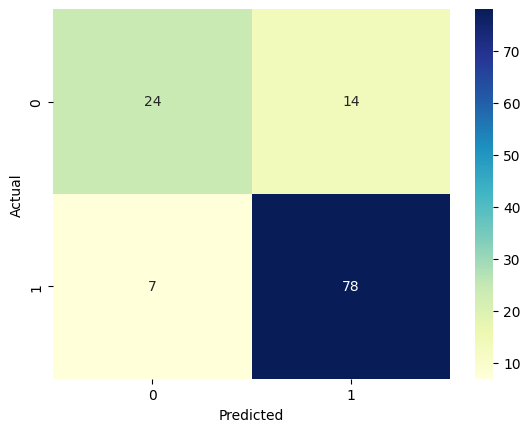

In [42]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [56]:
#Save the model
"""
joblib.dump(model, "loan_prediction_model.pkl")

model = joblib.load("loan_prediction_model.pkl")

from sklearn.ensemble import RandomForestClassifier
import joblib

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

joblib.dump(rf, "loan_prediction_model.pkl")

rf = joblib.load("loan_prediction_model.pkl")
joblib.dump(rf, "rf.pkl")
"""

'\njoblib.dump(model, "loan_prediction_model.pkl")\n\nmodel = joblib.load("loan_prediction_model.pkl")\n\nfrom sklearn.ensemble import RandomForestClassifier\nimport joblib\n\nrf = RandomForestClassifier(random_state=42)\n\nrf.fit(X_train, y_train)\n\njoblib.dump(rf, "loan_prediction_model.pkl")\n\nrf = joblib.load("loan_prediction_model.pkl")\njoblib.dump(rf, "rf.pkl")\n'

In [57]:
joblib.dump(model, "C:/Users/Bhumika gs/Loan Predection/model.pkl")

['C:/Users/Bhumika gs/Loan Predection/model.pkl']

SyntaxError: invalid syntax (3737097518.py, line 1)